# E1/E2 analysis template — paired seeds, validation frontier, and multiplicity

**TL;DR.** This notebook encodes the analysis contract before GPU results exist. The authoritative
`aggregate_e1_sweep.py` command verifies the complete plan, run/audit provenance, and paired seed
cells before it builds a validation-only safety/utility frontier. This notebook consumes only those
fail-closed aggregate artifacts; it never reconstructs a result from an opportunistic subset of run
directories and keeps final-test labels out of selection. The persisted numerical example is
explicitly synthetic and exists only to regression-test the statistics code. It is not evidence for
the method.

Once either 48-task domain component is complete, run the aggregator documented in the E1 handoff and
then rerun this notebook. Incomplete aggregates remain visible as a ledger but cannot become a real
result panel.

## Assumptions and analysis contract

- Pair by the same training seed within task/model/history/dimension; never pool video frames as
  independent replicates.
- Minimize both validation world-model utility loss and the prospectively frozen validation safety
  defect. Report reconstruction and maximum-predeclared-horizon rollout pixel MSE separately; the
  family-dependent composite is not a global AE-versus-beta-VAE matching scale.
- Use the radius and safety budget frozen in `configs/e1_world_models/decisive_cart_grid.toml`.
- Three seeds are exploratory. Confirmatory intervals require the selected eight-seed design (or a
  preregistered precision argument) and are reported with all failures/timeouts.
- Holm correction requires a predeclared hypothesis family and valid raw p-values; it cannot repair
  selective analysis.

In [1]:
from dataclasses import asdict
from pathlib import Path
import json
import sys
import tomllib

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.analysis import (
    BLOCK_INDEPENDENCE_CAVEAT,
    VALIDATION_SELECTION_CAVEAT,
    HypothesisPValue,
    PairedBlock,
    ValidationScore,
    exact_paired_sign_flip_test,
    holm_adjust,
    paired_block_bootstrap_ci,
    select_under_safety_budget,
    standardized_paired_effect,
    validation_pareto_frontier,
)

GRID_PATH = ROOT / "configs" / "e1_world_models" / "decisive_cart_grid.toml"
with GRID_PATH.open("rb") as stream:
    grid_config = tomllib.load(stream)
analysis_config = grid_config["analysis"]
display({
    "block_caveat": BLOCK_INDEPENDENCE_CAVEAT,
    "selection_caveat": VALIDATION_SELECTION_CAVEAT,
    "frozen_analysis_config": analysis_config,
})

{'block_caveat': 'Each PairedBlock must represent one independent seed or one pre-aggregated, predeclared environment/trajectory block. Never enter correlated frames as separate blocks.',
 'selection_caveat': 'Frontier construction and budget selection may use validation metrics only. Final-test safety labels must not select configurations, checkpoints, budgets, or stopping times.',
 'frozen_analysis_config': {'relative_radii': [0.0, 0.01, 0.02, 0.05, 0.1],
  'primary_relative_radius': 0.05,
  'max_validation_static_defect': 0.1,
  'bootstrap_resamples': 10000,
  'bootstrap_seed': 20260821,
  'selection_split': 'validation'}}

## 1. Fail-closed aggregate audit

In [2]:
aggregate_paths = {
    "cart": ROOT / "runs" / "analysis" / "e1_pilot_validation.json",
    "pendulum": ROOT / "runs" / "analysis" / "e1_pendulum_pilot_validation.json",
}
aggregate_reports = {}
aggregate_status = {}
for domain, path in aggregate_paths.items():
    if not path.is_file():
        aggregate_status[domain] = {
            "artifact": str(path),
            "status": "missing",
            "analysis_ready": False,
        }
        continue
    report = json.loads(path.read_text(encoding="utf-8"))
    if report.get("schema_version") != 1:
        raise RuntimeError(f"Unsupported aggregate schema for {domain}: {path}")
    if report.get("selection_uses_test_data") is not False:
        raise RuntimeError(f"Aggregate does not preserve validation-only selection: {path}")
    completeness = report.get("completeness", {})
    aggregate_status[domain] = {
        "artifact": str(path),
        "status": report.get("status"),
        "analysis_ready": bool(report.get("analysis_ready")),
        "planned_tasks": completeness.get("planned_task_count"),
        "successful_tasks": completeness.get("successful_task_count"),
        "missing_tasks": completeness.get("missing_task_count"),
        "failed_tasks": completeness.get("failed_task_count"),
        "test_unblinded": report.get("test_unblinded"),
    }
    if report.get("status") == "complete" and report.get("analysis_ready") is True:
        aggregate_reports[domain] = report

display(aggregate_status)

{'cart': {'artifact': '/Users/carloschreiber/Desktop/Uni/Research/ETH X STANFORD/ethxstanfordresearch/LatentSafety/runs/analysis/e1_pilot_validation.json',
  'status': 'missing',
  'analysis_ready': False},
 'pendulum': {'artifact': '/Users/carloschreiber/Desktop/Uni/Research/ETH X STANFORD/ethxstanfordresearch/LatentSafety/runs/analysis/e1_pendulum_pilot_validation.json',
  'status': 'missing',
  'analysis_ready': False}}

## 2. Synthetic regression fixture for paired inference

The values below are fabricated and labelled as such. They verify difference direction, seed
pairing, deterministic bootstrap output, and zero-variance handling. Smaller defect is better, so a
negative `candidate - baseline` estimate favors the candidate.

In [3]:
synthetic_baseline = (0.42, 0.39, 0.46, 0.41, 0.44, 0.38, 0.45, 0.43)
synthetic_candidate = (0.31, 0.35, 0.34, 0.36, 0.33, 0.32, 0.37, 0.34)
synthetic_blocks = tuple(
    PairedBlock(f"synthetic-seed-{seed}", baseline, candidate)
    for seed, (baseline, candidate) in enumerate(
        zip(synthetic_baseline, synthetic_candidate, strict=True)
    )
)
synthetic_ci = paired_block_bootstrap_ci(
    synthetic_blocks,
    resamples=int(analysis_config["bootstrap_resamples"]),
    seed=int(analysis_config["bootstrap_seed"]),
)
synthetic_effect = standardized_paired_effect(synthetic_blocks)
synthetic_randomization = exact_paired_sign_flip_test(
    synthetic_blocks,
    alternative="candidate_less",
    exchangeability_justification=(
        "synthetic paired method labels are exchangeable under the constructed sharp null"
    ),
)
display({
    "status": "SYNTHETIC CODE REGRESSION — NOT A RESULT",
    "paired_ci": asdict(synthetic_ci),
    "paired_effect": asdict(synthetic_effect),
    "exact_sign_flip": asdict(synthetic_randomization),
})
assert synthetic_ci.n_blocks == 8
assert synthetic_ci.estimate < 0.0
assert synthetic_effect.is_defined
assert synthetic_randomization.permutation_count == 2 ** len(synthetic_blocks)
assert synthetic_randomization.p_value == 1.0 / synthetic_randomization.permutation_count

{'status': 'SYNTHETIC CODE REGRESSION — NOT A RESULT',
 'paired_ci': {'statistic': 'mean',
  'estimate': -0.08249999999999999,
  'lower': -0.10124999999999999,
  'upper': -0.0625,
  'confidence_level': 0.95,
  'resamples': 10000,
  'rng_seed': 20260821,
  'n_blocks': 8,
  'difference_convention': 'candidate - baseline',
  'resampling_unit': 'paired seed/pre-aggregated block',
  'method': 'paired percentile bootstrap'},
 'paired_effect': {'value': -2.7391518314809633,
  'mean_difference': -0.08249999999999999,
  'sample_sd_difference': 0.030118812346154298,
  'n_blocks': 8,
  'status': 'defined',
  'definition': 'Cohen d_z = mean(candidate - baseline) / sample SD(candidate - baseline)'},
 'exact_sign_flip': {'estimate': -0.08249999999999999,
  'p_value': 0.00390625,
  'alternative': 'candidate_less',
  'n_blocks': 8,
  'permutation_count': 256,
  'exchangeability_justification': 'synthetic paired method labels are exchangeable under the constructed sharp null',
  'difference_convention'

## 3. Validation-only Pareto selection regression

In [4]:
synthetic_validation_scores = (
    ValidationScore("baseline", safety_defect=0.42, utility_loss=0.20),
    ValidationScore("h_prediction", safety_defect=0.31, utility_loss=0.22),
    ValidationScore("boundary", safety_defect=0.22, utility_loss=0.25),
    ValidationScore("action_profile", safety_defect=0.18, utility_loss=0.29),
    ValidationScore("dominated_control", safety_defect=0.45, utility_loss=0.30),
)
synthetic_frontier = validation_pareto_frontier(synthetic_validation_scores)
synthetic_selection = select_under_safety_budget(
    synthetic_frontier,
    max_safety_defect=0.25,
)
display({
    "status": "SYNTHETIC CODE REGRESSION — NOT A RESULT",
    "frontier": [asdict(point) for point in synthetic_frontier.points],
    "dominated": synthetic_frontier.dominated_config_ids,
    "selected_under_synthetic_budget_0.25": asdict(synthetic_selection),
})
assert "dominated_control" in synthetic_frontier.dominated_config_ids
assert synthetic_selection.config_id == "boundary"

{'status': 'SYNTHETIC CODE REGRESSION — NOT A RESULT',
 'frontier': [{'config_id': 'action_profile',
   'safety_defect': 0.18,
   'utility_loss': 0.29},
  {'config_id': 'boundary', 'safety_defect': 0.22, 'utility_loss': 0.25},
  {'config_id': 'h_prediction', 'safety_defect': 0.31, 'utility_loss': 0.22},
  {'config_id': 'baseline', 'safety_defect': 0.42, 'utility_loss': 0.2}],
 'dominated': ('dominated_control',),
 'selected_under_synthetic_budget_0.25': {'config_id': 'boundary',
  'safety_defect': 0.22,
  'utility_loss': 0.25}}

## 4. Multiplicity-control regression

In [5]:
synthetic_holm = holm_adjust(
    (
        HypothesisPValue("synthetic_H_static", 0.008),
        HypothesisPValue("synthetic_H_action", 0.021),
        HypothesisPValue("synthetic_H_downstream", 0.11),
    ),
    alpha=0.05,
)
display({
    "status": "SYNTHETIC CODE REGRESSION — NOT A RESULT",
    "holm": [asdict(item) for item in synthetic_holm],
})
assert [item.rejected for item in synthetic_holm] == [True, True, False]

{'status': 'SYNTHETIC CODE REGRESSION — NOT A RESULT',
 'holm': [{'hypothesis_id': 'synthetic_H_static',
   'raw_p_value': 0.008,
   'adjusted_p_value': 0.024,
   'rank': 1,
   'step_down_threshold': 0.016666666666666666,
   'rejected': True,
   'alpha': 0.05,
   'family_size': 3},
  {'hypothesis_id': 'synthetic_H_action',
   'raw_p_value': 0.021,
   'adjusted_p_value': 0.042,
   'rank': 2,
   'step_down_threshold': 0.025,
   'rejected': True,
   'alpha': 0.05,
   'family_size': 3},
  {'hypothesis_id': 'synthetic_H_downstream',
   'raw_p_value': 0.11,
   'adjusted_p_value': 0.11,
   'rank': 3,
   'step_down_threshold': 0.05,
   'rejected': False,
   'alpha': 0.05,
   'family_size': 3}]}

## 5. Visual regression checks

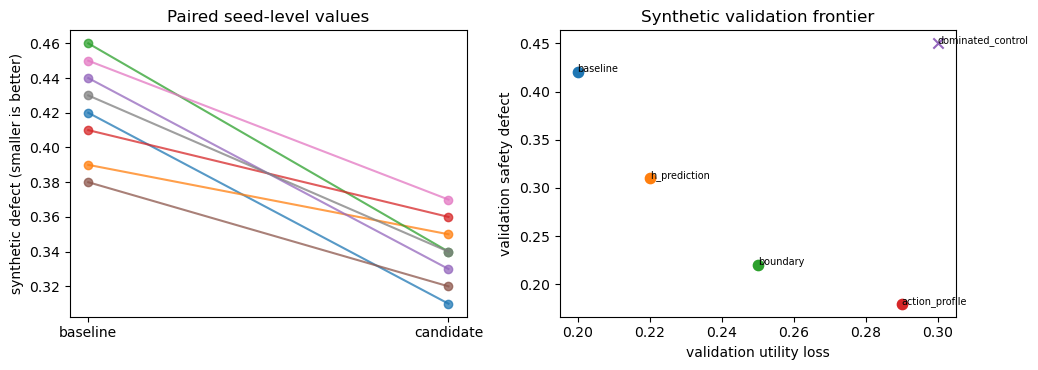

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
seed_indices = np.arange(len(synthetic_baseline))
for seed, baseline, candidate in zip(
    seed_indices, synthetic_baseline, synthetic_candidate, strict=True
):
    axes[0].plot([0, 1], [baseline, candidate], marker="o", alpha=0.75)
axes[0].set_xticks([0, 1], ["baseline", "candidate"])
axes[0].set_ylabel("synthetic defect (smaller is better)")
axes[0].set_title("Paired seed-level values")

for point in synthetic_validation_scores:
    on_frontier = point in synthetic_frontier.points
    axes[1].scatter(
        point.utility_loss,
        point.safety_defect,
        marker="o" if on_frontier else "x",
        s=55,
    )
    axes[1].annotate(point.config_id, (point.utility_loss, point.safety_defect), fontsize=7)
axes[1].set(xlabel="validation utility loss", ylabel="validation safety defect")
axes[1].set_title("Synthetic validation frontier")
fig.tight_layout()
plt.show()

## 6. Real pilot aggregate display (only complete, provenance-checked artifacts)

Frontier construction and paired inference happen in the fail-closed aggregator, which validates
the declared plan hash, factorial coverage, checkpoint provenance, audit radii, and complete seed
cells. This cell displays only reports whose status is `complete` and `analysis_ready`; a partial or
rejected report cannot enter. The final test table belongs in a separate, locked unblinding step
after the rule and included seeds are frozen.

In [7]:
if aggregate_reports:
    for domain, report in sorted(aggregate_reports.items()):
        frontier = report["validation_frontier"]
        utility_component_rows = [
            {
                "config_id": row["config_id"],
                "model_family": row["model_family"],
                "history_mode": row["history_mode"],
                "safety_arm": row["safety_arm"],
                "median_selection_composite": row["validation_median"]["utility_loss"],
                "median_reconstruction_mse": row["validation_median"]["reconstruction_mse"],
                "median_rollout_pixel_mse": row["validation_median"][
                    "rollout_pixel_mse_at_max_horizon"
                ],
                "rollout_horizon": row["rollout_summary_horizon"],
            }
            for row in report["model_rows"]
        ]
        display({
            "status": "REAL COMPLETE VALIDATION-ONLY PILOT AGGREGATE",
            "domain": domain,
            "source_plan_sha256": report["source_plan"]["plan_sha256"],
            "successful_tasks": report["completeness"]["successful_task_count"],
            "complete_seed_model_cells": len(report["model_rows"]),
            "frontier": frontier["points"],
            "predeclared_selection_status": frontier["budget_selection_status"],
            "predeclared_selection": frontier["selected"],
            "utility_component_rows": utility_component_rows,
            "paired_comparison_count": len(report["paired_seed_comparisons"]),
            "test_access": report["analysis_contract"]["test_access"],
        })
else:
    display(Markdown(
        "**No complete, analysis-ready GPU pilot aggregates found.** This is the expected "
        "repository state before the sweeps; only the explicitly synthetic regression outputs "
        "above are active. Run `scripts/aggregate_e1_sweep.py` after every planned task has "
        "finished."
    ))

**No complete, analysis-ready GPU pilot aggregates found.** This is the expected repository state before the sweeps; only the explicitly synthetic regression outputs above are active. Run `scripts/aggregate_e1_sweep.py` after every planned task has finished.

## Takeaways and unblinding gate

The inferential machinery is executable before results arrive: paired seed/block bootstrap,
explicit standardized-effect edge cases, Holm step-down correction, and validation-only Pareto
selection. The notebook refuses to invent a real aggregate when run/audit artifacts are missing.

Before any confirmatory test unblinding, freeze: included configuration IDs and failed runs; the
primary radius; safety budget; effect direction; resampling unit; hypothesis family; and exact
producing commit/environment. The current trainer's three-seed pilot evaluates test for engineering
convenience, so it is exploratory. A final study should use a deferred-test execution path or an
independent custodian to preserve a genuine blind.